# Comparison: LLM Explanation With vs Without XAI

Two **separate chats** per model to compare explanations:
- **Chat A (Without XAI):** Model info + column descriptions + real vs predicted → explanation
- **Chat B (With XAI):** Model info + column descriptions + real vs predicted + SHAP + LIME → explanation

Both chats receive the **same analysis prompt** so outputs are directly comparable.

In [1]:
import pandas as pd
import numpy as np
import json
import time
import shap
import lime
from lime import lime_tabular
from openai import OpenAI
import httpx
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
# ==========================
# CONFIGURAÇÃO DO OLLAMA
# ==========================
OLLAMA_BASE_URL = "http://localhost:11434/v1"
REQUEST_TIMEOUT = 900.0  # 15 minutos por request

models = [
    {"name": "glm-4.7-flash:latest",  "size": "medium"},
    {"name": "qwen3:14b",              "size": "medium"},
    {"name": "gpt-oss:20b",            "size": "medium"},
    {"name": "qwen3:30b",              "size": "large"},
]

# Leitura e Pre-processamento dos Dados

In [3]:
df = pd.read_csv("./Network_logs.csv")

In [4]:
networkData = df.copy()
networkData.drop(['Source_IP', 'Destination_IP', 'Intrusion'], axis=1, inplace=True)
networkData.head(5)

,Port,Request_Type,Protocol,Payload_Size,User_Agent,Status,Scan_Type
0,80,FTP,UDP,2369,curl/7.68.0,Success,Normal
1,135,SMTP,UDP,1536,Wget/1.20.3,Failure,BotAttack
2,21,SMTP,TCP,1183,Wget/1.20.3,Success,Normal
3,25,HTTPS,TCP,666,Mozilla/5.0,Success,Normal
4,22,FTP,TCP,2821,Mozilla/5.0,Success,Normal


In [5]:
categorical_cols = ['Request_Type', 'Protocol', 'User_Agent', 'Status', 'Port']
for col in categorical_cols:
    networkData[col] = networkData[col].astype('category')

for col in categorical_cols:
    print(f"{col} categories: {networkData[col].cat.categories.tolist()}")

for col in categorical_cols:
    networkData[col] = networkData[col].cat.codes

Request_Type categories: ['DNS', 'FTP', 'HTTP', 'HTTPS', 'SMTP', 'SSH', 'Telnet']
Protocol categories: ['ICMP', 'TCP', 'UDP']
User_Agent categories: ['Mozilla/5.0', 'Nikto/2.1.6', 'Wget/1.20.3', 'curl/7.68.0', 'nmap/7.80', 'python-requests/2.25.1']
Status categories: ['Failure', 'Success']
Port categories: [21, 22, 23, 25, 53, 80, 135, 443, 4444, 6667, 8080, 31337]


In [6]:
target_encoder = LabelEncoder()
networkData['Scan_Type_Label'] = target_encoder.fit_transform(networkData['Scan_Type'])

label_mapping = dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_)))
print("Label Mapping:", label_mapping)

networkData.drop(['Scan_Type'], axis=1, inplace=True)
networkData.head(5)

Label Mapping: {'BotAttack': np.int64(0), 'Normal': np.int64(1), 'PortScan': np.int64(2)}


,Port,Request_Type,Protocol,Payload_Size,User_Agent,Status,Scan_Type_Label
0,5,1,2,2369,3,1,1
1,6,4,2,1536,2,0,0
2,0,4,1,1183,2,1,1
3,3,3,1,666,0,1,1
4,1,1,1,2821,0,1,1


In [7]:
scaler = StandardScaler()
networkData['Payload_Size'] = scaler.fit_transform(networkData[['Payload_Size']])

X = networkData.drop(['Scan_Type_Label'], axis=1)
y = networkData['Scan_Type_Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [8]:
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)
y_train = pd.Series(y_train.values.ravel(), name='Scan_Type_Label')

print('SMOTE aplicado com sucesso.\n')
print('Nova distribuição:\n')
print(y_train.value_counts())

SMOTE aplicado com sucesso.

Nova distribuição:

Scan_Type_Label
1    5600
0    5600
2    5600
Name: count, dtype: int64


# Treinamento do Modelo

In [9]:
model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acc:.4f}")
print(classification_report(y_test, y_pred))

Acurácia: 0.9970
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       144
           1       1.00      1.00      1.00      2400
           2       0.99      1.00      1.00       110

    accuracy                           1.00      2654
   macro avg       0.99      0.99      0.99      2654
weighted avg       1.00      1.00      1.00      2654



# Explicabilidade SHAP + LIME

/tmp/ipykernel_2485262/600580879.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)


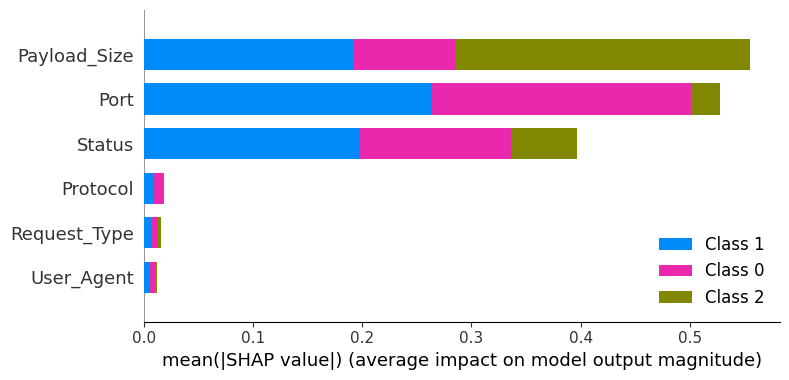

In [10]:
feature_names = list(X.columns)
class_names = list(target_encoder.classes_)

np.random.seed(42)
sample_idx = np.random.choice(X_test.index, size=min(200, len(X_test)), replace=False)
X_sample = X_test.loc[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)

In [11]:
shap_global = {}
for cls_idx, cls_name in enumerate(class_names):
    mean_abs = np.abs(shap_values[:, :, cls_idx]).mean(axis=0)
    shap_global[cls_name] = {feat: round(float(val), 6) for feat, val in zip(feature_names, mean_abs)}

shap_global_json = json.dumps(shap_global, indent=2, ensure_ascii=False)
print("SHAP - Importancia Global por Classe:")
print(shap_global_json)

SHAP - Importancia Global por Classe:
{
  "BotAttack": {
    "Port": 0.237165,
    "Request_Type": 0.007052,
    "Protocol": 0.008229,
    "Payload_Size": 0.092703,
    "User_Agent": 0.004945,
    "Status": 0.137799
  },
  "Normal": {
    "Port": 0.263565,
    "Request_Type": 0.006524,
    "Protocol": 0.009127,
    "Payload_Size": 0.191922,
    "User_Agent": 0.005783,
    "Status": 0.198339
  },
  "PortScan": {
    "Port": 0.026795,
    "Request_Type": 0.002407,
    "Protocol": 0.001163,
    "Payload_Size": 0.269966,
    "User_Agent": 0.001405,
    "Status": 0.060541
  }
}


In [12]:
n_local = 5
shap_local = []
for idx in range(n_local):
    sample_row = X_sample.iloc[idx]
    real_idx = X_sample.index[idx]
    entry = {
        "instance_features": {feat: round(float(sample_row[feat]), 4) for feat in feature_names},
        "true_label": class_names[int(y_test.loc[real_idx])],
        "predicted_label": class_names[int(model.predict(sample_row.to_frame().T)[0])],
        "shap_values_per_class": {}
    }
    for cls_idx, cls_name in enumerate(class_names):
        entry["shap_values_per_class"][cls_name] = {
            feat: round(float(shap_values[idx, f_idx, cls_idx]), 6)
            for f_idx, feat in enumerate(feature_names)
        }
    shap_local.append(entry)

shap_local_json = json.dumps(shap_local, indent=2, ensure_ascii=False)
print("SHAP - Explicacoes Locais (5 instancias):")
print(shap_local_json[:1000], "...")

SHAP - Explicacoes Locais (5 instancias):
[
  {
    "instance_features": {
      "Port": 2.0,
      "Request_Type": 1.0,
      "Protocol": 1.0,
      "Payload_Size": 1.6484,
      "User_Agent": 4.0,
      "Status": 1.0
    },
    "true_label": "BotAttack",
    "predicted_label": "BotAttack",
    "shap_values_per_class": {
      "BotAttack": {
        "Port": 0.084985,
        "Request_Type": 0.004816,
        "Protocol": 0.019514,
        "Payload_Size": 0.559345,
        "User_Agent": -0.021538,
        "Status": -0.100509
      },
      "Normal": {
        "Port": -0.074088,
        "Request_Type": -0.005014,
        "Protocol": -0.021196,
        "Payload_Size": -0.299377,
        "User_Agent": 0.021065,
        "Status": 0.165361
      },
      "PortScan": {
        "Port": -0.010898,
        "Request_Type": 0.000198,
        "Protocol": 0.001682,
        "Payload_Size": -0.259968,
        "User_Agent": 0.000473,
        "Status": -0.064852
      }
    }
  },
  {
    "instance_feat

In [13]:
import warnings

explainer_l = lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification'
)

lime_explanations = []
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="X does not have valid feature names")
    for idx in range(n_local):
        sample_row = X_sample.iloc[idx]
        real_idx = X_sample.index[idx]

        exp = explainer_l.explain_instance(
            sample_row.values,
            model.predict_proba,
            num_features=6
        )

        lime_explanations.append({
            "instance_index": int(real_idx),
            "true_label": class_names[int(y_test.loc[real_idx])],
            "predicted_label": class_names[int(model.predict(sample_row.to_frame().T)[0])],
            "local_prediction_proba": {
                cls: round(float(p), 4)
                for cls, p in zip(class_names, model.predict_proba(sample_row.to_frame().T)[0])
            },
            "feature_contributions": [
                {"rule": rule, "weight": round(float(w), 6)} for rule, w in exp.as_list()
            ]
        })

lime_explanations_json = json.dumps(lime_explanations, indent=2, ensure_ascii=False)
print("LIME - Explicacoes Locais (5 instancias):")
print(lime_explanations_json[:1000], "...")

LIME - Explicacoes Locais (5 instancias):
[
  {
    "instance_index": 6094,
    "true_label": "BotAttack",
    "predicted_label": "BotAttack",
    "local_prediction_proba": {
      "BotAttack": 0.88,
      "Normal": 0.12,
      "PortScan": 0.0
    },
    "feature_contributions": [
      {
        "rule": "Port <= 3.00",
        "weight": 0.287075
      },
      {
        "rule": "Payload_Size > 0.93",
        "weight": -0.131406
      },
      {
        "rule": "0.00 < Status <= 1.00",
        "weight": 0.112733
      },
      {
        "rule": "2.00 < User_Agent <= 4.00",
        "weight": -0.011117
      },
      {
        "rule": "0.00 < Protocol <= 1.00",
        "weight": 0.004817
      },
      {
        "rule": "Request_Type <= 1.00",
        "weight": 0.0026
      }
    ]
  },
  {
    "instance_index": 8649,
    "true_label": "Normal",
    "predicted_label": "Normal",
    "local_prediction_proba": {
      "BotAttack": 0.0,
      "Normal": 1.0,
      "PortScan": 0.0
    },
    "

# Construção dos Prompts (Chat A vs Chat B)

In [14]:
# ==========================
# METADADOS DO MODELO E DATASET
# ==========================
column_description = {
    "Port": "Communication port (encoded: 21=0, 22=1, 23=2, 25=3, 53=4, 80=5, 135=6, 443=7, 4444=8, 6667=9, 8080=10, 31337=11)",
    "Request_Type": "Request type (DNS=0, FTP=1, HTTP=2, HTTPS=3, SMTP=4, SSH=5, Telnet=6)",
    "Protocol": "Transport protocol (ICMP=0, TCP=1, UDP=2)",
    "Payload_Size": "Packet payload size (StandardScaler normalized)",
    "User_Agent": "Client agent (Mozilla/5.0=0, Nikto/2.1.6=1, Wget/1.20.3=2, curl/7.68.0=3, nmap/7.80=4, python-requests/2.25.1=5)",
    "Status": "Request status (Failure=0, Success=1)",
    "Scan_Type_Label": "Target variable: BotAttack=0, Normal=1, PortScan=2"
}

model_info = {
    "type": "Random Forest",
    "task": "Network intrusion detection from log entries",
    "target": "Scan_Type_Label",
    "classes": {"BotAttack": 0, "Normal": 1, "PortScan": 2},
    "features": list(X.columns),
    "accuracy": round(float(accuracy_score(y_test, y_pred)), 4)
}

# Samples (20 records)
train_sample = X_train.sample(20, random_state=42)
train_sample["Scan_Type_Label"] = y_train.loc[train_sample.index]
train_sample_json = train_sample.to_json(orient="records")

pred_sample = pd.DataFrame({"real": y_test, "predicted": y_pred})
pred_sample_json = pred_sample.sample(20, random_state=42).to_json(orient="records")

In [15]:
# ==========================
# SYSTEM MESSAGES
# ==========================
system_msg = (
    "You are an expert in Machine Learning, Explainable AI, and Cybersecurity. "
    "You will receive data about an intrusion detection model in multiple messages. "
    "After each message, briefly summarize the key data you received (do NOT analyze yet). "
    "When you receive 'OK, start your analysis.', produce your full structured analysis "
    "using ALL data from ALL previous messages."
)

# ==========================
# SHARED DATA MESSAGES
# ==========================
msg_model_info = f"""I will send you data about a network intrusion detection model in parts.
After each part, briefly summarize what you received. Do NOT analyze yet.

# Part 1: Model Info & Column Descriptions

## Model
{json.dumps(model_info, indent=2, ensure_ascii=False)}

## Column Descriptions (all features are numerically encoded)
{json.dumps(column_description, indent=2, ensure_ascii=False)}"""

msg_train = f"""# Part 2: Training Data Sample (20 records)
{train_sample_json}"""

msg_pred = f"""# Part 3: Real vs Predicted Labels (20 records)
{pred_sample_json}"""

msg_shap_global = f"""# Part 4: SHAP Global Feature Importance

Mean |SHAP| per feature per class, computed over {len(X_sample)} test samples:
{shap_global_json}"""

msg_shap_local = f"""# Part 5: SHAP Local Explanations (5 instances)
{shap_local_json}"""

msg_lime = f"""# Part 6: LIME Local Explanations (same 5 instances as SHAP)
{lime_explanations_json}"""

# ==========================
# IDENTICAL ANALYSIS PROMPT (used in both chats)
# ==========================
analysis_prompt_base = """# OK, start your analysis.

Provide a detailed, structured analysis:

1. **Global Feature Importance:** Which features are most important for distinguishing
   BotAttack vs Normal vs PortScan? Rank them and explain why from a cybersecurity perspective.

2. **Misclassification Analysis:** Identify incorrect predictions from the real vs predicted data.
   For each, explain why the model likely got it wrong based on the available evidence.

3. **Local Instance Analysis:** For the specific instances you have data on, explain what drove
   each prediction. What features were decisive?

4. **Cybersecurity Insights:** What are the strongest indicators of BotAttack vs PortScan?
   How could a SOC analyst use these patterns in practice?

5. **Model Reliability:** How reliable is this model? What are its strengths and weaknesses?

6. **Improvement Suggestions:** Concrete improvements based on the evidence you have.

Use numbered sections and subsections."""

# Chat A task: without XAI
chat_a_task = f"""# OK, start your analysis.

You have received:
- Model info (Random Forest, 3-class intrusion detection) + column descriptions
- 20 training records
- 20 real vs predicted labels

{analysis_prompt_base.split('# OK, start your analysis.')[1]}"""

# Chat B task: with XAI
chat_b_task = f"""# OK, start your analysis.

You have received:
- Model info (Random Forest, 3-class intrusion detection) + column descriptions
- 20 training records
- 20 real vs predicted labels
- SHAP global feature importance per class
- SHAP local explanations for 5 instances
- LIME local explanations for the same 5 instances

Key SHAP global values (for reference):
{shap_global_json}

{analysis_prompt_base.split('# OK, start your analysis.')[1]}"""

# ==========================
# CHAT STRUCTURES
# ==========================

# Chat A: Without XAI
chat_a_chunks = [
    {"user": msg_model_info},
    {"user": msg_train},
    {"user": msg_pred},
    {"user": chat_a_task, "is_analysis": True},
]

# Chat B: With XAI
chat_b_chunks = [
    {"user": msg_model_info},
    {"user": msg_train},
    {"user": msg_pred},
    {"user": msg_shap_global},
    {"user": msg_shap_local},
    {"user": msg_lime},
    {"user": chat_b_task, "is_analysis": True},
]

print("Chat A (Without XAI):")
for i, chunk in enumerate(chat_a_chunks, 1):
    print(f"  Msg {i}: {len(chunk['user'])} chars {'[ANALYSIS]' if chunk.get('is_analysis') else ''}")
print(f"  Total: {sum(len(c['user']) for c in chat_a_chunks)} chars")

print("\nChat B (With XAI):")
for i, chunk in enumerate(chat_b_chunks, 1):
    print(f"  Msg {i}: {len(chunk['user'])} chars {'[ANALYSIS]' if chunk.get('is_analysis') else ''}")
print(f"  Total: {sum(len(c['user']) for c in chat_b_chunks)} chars")

Chat A (Without XAI):
  Msg 1: 1207 chars 
  Msg 2: 2351 chars 
  Msg 3: 549 chars 
  Msg 4: 1112 chars [ANALYSIS]
  Total: 5219 chars

Chat B (With XAI):
  Msg 1: 1207 chars 
  Msg 2: 2351 chars 
  Msg 3: 549 chars 
  Msg 4: 650 chars 
  Msg 5: 4688 chars 
  Msg 6: 3813 chars 
  Msg 7: 1831 chars [ANALYSIS]
  Total: 15089 chars


# Execução: Chat A vs Chat B per Model

In [16]:
def run_chat(client, model_name, model_size, chat_chunks, chat_label):
    """Run a multi-turn chat and return the final analysis text."""
    messages = [{"role": "system", "content": system_msg}]
    max_tokens_analysis = 16384 if model_size == "large" else 8192
    n_msgs = len(chat_chunks)

    for i, chunk in enumerate(chat_chunks):
        is_analysis = chunk.get("is_analysis", False)
        messages.append({"role": "user", "content": chunk["user"]})

        if not is_analysis:
            response = client.chat.completions.create(
                model=model_name,
                messages=messages,
                max_tokens=256
            )
            summary = response.choices[0].message.content.strip()
            messages.append({"role": "assistant", "content": summary})
            print(f"    {chat_label} Msg {i+1}/{n_msgs} -> {summary[:80]}")
        else:
            print(f"    {chat_label} Msg {i+1}/{n_msgs} -> requesting analysis...")
            response = client.chat.completions.create(
                model=model_name,
                messages=messages,
                max_tokens=max_tokens_analysis
            )
            result = response.choices[0].message.content
            print(f"    {chat_label} analysis done: {len(result)} chars")
            return result

    return "ERROR: no analysis message found"

In [17]:
# ==========================
# RUN CHAT A AND CHAT B FOR EACH MODEL
# ==========================
client = OpenAI(
    base_url=OLLAMA_BASE_URL,
    api_key="ollama",
    timeout=httpx.Timeout(REQUEST_TIMEOUT, connect=30.0),
)

results = {}
timings = {}
previous_model = None

for model_cfg in models:
    model_name = model_cfg["name"]
    model_size = model_cfg["size"]

    if previous_model:
        !ollama stop $previous_model
        time.sleep(2)

    print(f"\n{'='*60}")
    print(f"Modelo: {model_name} (tier: {model_size})")
    print(f"{'='*60}")

    model_results = {}
    t_start = time.time()

    try:
        # ---- Chat A: Without XAI ----
        print(f"\n  --- Chat A: Without XAI ---")
        t_a = time.time()
        model_results["chat_a_without_xai"] = run_chat(
            client, model_name, model_size, chat_a_chunks, "ChatA"
        )
        print(f"  Chat A time: {time.time() - t_a:.1f}s")

        # ---- Chat B: With XAI (fresh chat) ----
        print(f"\n  --- Chat B: With XAI ---")
        t_b = time.time()
        model_results["chat_b_with_xai"] = run_chat(
            client, model_name, model_size, chat_b_chunks, "ChatB"
        )
        print(f"  Chat B time: {time.time() - t_b:.1f}s")

    except Exception as e:
        model_results["error"] = str(e)
        print(f"  Error: {e}")

    elapsed = time.time() - t_start
    timings[model_name] = elapsed
    results[model_name] = model_results
    print(f"\n  Total for {model_name}: {elapsed:.1f}s")

    previous_model = model_name

if previous_model:
    !ollama stop $previous_model

print("\nAll models completed.\n")
print("Time per model:")
for name, t in timings.items():
    print(f"  {name}: {t:.1f}s")


Modelo: glm-4.7-flash:latest (tier: medium)

  --- Chat A: Without XAI ---
    ChatA Msg 1/4 -> 
    ChatA Msg 2/4 -> 
    ChatA Msg 3/4 -> 
    ChatA Msg 4/4 -> requesting analysis...
    ChatA analysis done: 6706 chars
  Chat A time: 439.0s

  --- Chat B: With XAI ---
    ChatB Msg 1/7 -> 
    ChatB Msg 2/7 -> 
    ChatB Msg 3/7 -> 
    ChatB Msg 4/7 -> 
    ChatB Msg 5/7 -> 
    ChatB Msg 6/7 -> 
    ChatB Msg 7/7 -> requesting analysis...
    ChatB analysis done: 5532 chars
  Chat B time: 488.4s

  Total for glm-4.7-flash:latest: 927.4s
]11;?\⠙ ⠹ ⠹ 
Modelo: qwen3:14b (tier: medium)

  --- Chat A: Without XAI ---
    ChatA Msg 1/4 -> 
    ChatA Msg 2/4 -> 
    ChatA Msg 3/4 -> 
    ChatA Msg 4/4 -> requesting analysis...
    ChatA analysis done: 4355 chars
  Chat A time: 177.0s

  --- Chat B: With XAI ---
    ChatB Msg 1/7 -> 
    ChatB Msg 2/7 -> 
    ChatB Msg 3/7 -> 
    ChatB Msg 4/7 -> 
    ChatB Msg 5/7 -> 
    ChatB Msg 6/7 -> 
    ChatB Msg 7/7 -> requesting analysis...
 

# Resultados: Comparação Chat A vs Chat B

In [18]:
for model_name, model_results in results.items():
    print(f"\n{'='*60}")
    print(f"MODELO: {model_name}")
    print(f"{'='*60}")

    if "chat_a_without_xai" in model_results:
        r = model_results["chat_a_without_xai"]
        print(f"\n--- CHAT A: Without XAI ({len(r)} chars) ---\n")
        print(r)

    if "chat_b_with_xai" in model_results:
        r = model_results["chat_b_with_xai"]
        print(f"\n--- CHAT B: With XAI ({len(r)} chars) ---\n")
        print(r)

    if "error" in model_results:
        print(f"\nERROR: {model_results['error']}")

    print()


MODELO: glm-4.7-flash:latest

--- CHAT A: Without XAI (6706 chars) ---

Based on the provided dataset (20 sample entries), feature distribution, and encoded values, here is the comprehensive analysis of the model and the traffic patterns.

### 1. Global Feature Importance Analysis
While the specific feature importance scores (e.g., Gini importance or SHAP values) were not explicitly printed in the text, we can infer their importance based on the traffic patterns distinguishing "Normal" from "BotAttack/Scanning" traffic within the sample.

**Hierarchy of Influence:**

1.  **Payload Size (Likely the most influential):**
    *   *Reasoning:* In network security, the volume of data transferred is often the primary differentiator between static, legitimate traffic and active reconnaissance or exploitation. The training data shows high payload deviations (StandardScaler values > 3.0) almost exclusively in the BotAttack/Scanning classes. High payloads indicate tools are actively pulling dire

In [19]:
with open("resultados_comparison_with_without_xai.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print("Resultados salvos em resultados_comparison_with_without_xai.json")

Resultados salvos em resultados_comparison_with_without_xai.json
